# SFINCS Scenario Stats

> **Stage Contract**
>
> Requires: scenario folders and completed run_outputs/evt_* results
>
> Produces: scenario statistics and evaluation products under data/sfincs/stats
>
> Next: publish results or iterate on source/scenario settings

In [1]:
# Load local packages and this Location Workspace.
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
workspace = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists())
config_yaml = workspace / "config.yaml"

# Load notebook tools.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

from sfincs_runs.config import load_runtime
from sfincs_runs.scenarios import scenario_stats as stats

config, paths = load_runtime(config_yaml)
pd.set_option("display.max_columns", 80)


## Step 0: Load Stats Inputs

Stats are not raw SFINCS outputs alone. They need three folder families:

- `scenarios_root`: prepared SFINCS event folders with `sfincs.inp`, `sfincs.bzs`, and manifests.
- `storage_root`: persisted solver outputs, especially `sfincs_map.nc`.
- `design_outputs_root`: `design_events` outputs that explain the sampled peak, template, return period, and SLR scenario.

These paths come from `sfincs_runs/project.yaml` through `build_paths()`.

In [2]:
settings = pd.Series(
    {
        "scenarios_root": str(paths["scenarios_root"]),
        "storage_root": str(paths["storage_root"]),
        "stats_root": str(paths["stats_root"]),
        "design_outputs_root": str(paths["design_outputs_root"]),
        "land_threshold_m": 0.0,
        "huthresh_m": 0.01,
        "impact_threshold_m": 0.10,
    },
    name="value",
)
settings

scenarios_root         /home/grahamhults/projects/Flood-RM/locations/...
storage_root           /home/grahamhults/projects/Flood-RM/locations/...
stats_root             /home/grahamhults/projects/Flood-RM/locations/...
design_outputs_root    /home/grahamhults/projects/Flood-RM/locations/...
land_threshold_m                                                     0.0
huthresh_m                                                          0.01
impact_threshold_m                                                   0.1
Name: value, dtype: object

## Step 1

- Which SLR scenario generated this run?
- What return period was sampled?
- Which historical hydrograph template shaped the event?
- Does the SFINCS boundary file match the expected design-event peak?

In [3]:
scenario_summary, scenario_rows = stats.load_scenario_build(paths["scenarios_root"])
design_rows, design_attrs = stats.load_design_events(scenario_summary)

display(pd.Series(scenario_summary, name="scenario_build"))
display(pd.Series(design_attrs, name="design_event_attrs"))

design_frame = pd.DataFrame.from_dict(design_rows, orient="index")
cols = [c for c in ["sample_rp_years", "peak_m", "absolute_peak_m", "template_id", "template_peak_time", "tail_morph_factor"] if c in design_frame]
design_frame[cols].head()

base_model_root           /home/grahamhults/projects/Flood-RM/locations/...
design_outputs_root       /home/grahamhults/projects/Flood-RM/locations/...
design_scenario                                                        base
elapsed_seconds                                                 1908.279886
event_count                                                             500
forcing_variable                                                       auto
include_precip                                                         True
include_waves                                                          True
resume                                                                False
skipped_existing_count                                                    0
static_file_strategy                                     hardlink_then_copy
surge_dataset             /home/grahamhults/projects/Flood-RM/locations/...
target_scenarios_dir      /home/grahamhults/projects/Flood-RM/locations/...
written_coun

scenario_name    base
slr_offset_m      0.0
Name: design_event_attrs, dtype: object

,sample_rp_years,peak_m,absolute_peak_m,template_id,template_peak_time,tail_morph_factor
evt_0001,0.147906,1.881923,1.749489,tpl_0194,1984-08-28 04:00:00,1.000000
evt_0002,0.044461,1.671398,2.168041,tpl_1083,2013-03-08 13:00:00,1.000000
evt_0003,7.776219,2.575918,2.642051,tpl_1238,2018-01-04 17:00:00,1.037922
evt_0004,0.274365,1.990146,1.931400,tpl_0159,1983-08-10 04:00:00,1.000000
evt_0005,0.138144,1.869963,1.692793,tpl_0193,1984-07-31 05:00:00,1.000000


## Step 2: Pick Completed Events

A scenario folder is prepared input. A completed run also has `sfincs_map.nc` in the storage folder.

The next cell finds prepared events and keeps only events with map output, so the notebook can run safely on a subset.

In [4]:
all_events = stats.event_dirs(paths["scenarios_root"])
completed_events = [d for d in all_events if (paths["storage_root"] / d.name / "sfincs_map.nc").exists()]

LIMIT = 12  # set to None for all completed events
selected_events = completed_events[:LIMIT] if LIMIT is not None else completed_events

pd.Series(
    {
        "prepared_event_count": len(all_events),
        "completed_event_count": len(completed_events),
        "selected_event_count": len(selected_events),
        "first_selected_event": selected_events[0].name if selected_events else None,
    }
)

prepared_event_count          500
completed_event_count         500
selected_event_count           12
first_selected_event     evt_0001
dtype: object

## Step 2b: Health Check All Runs

Before trusting any aggregate, confirm each event finished cleanly. This cell walks every event in `completed_events` and flags anomalies on three axes:

- `returncode` from `run_metadata.json` (should be 0).
- `sfincs_map.nc` file size (a normal run is tens of MB; near zero means the solver wrote no map output).
- finite-value fraction of the final-timestep `zs` slice (near zero means the solver wrote NaNs across the active grid).

Also surfaces per-event wall-clock duration so outliers — events much slower than the rest — are visible before any downstream analysis. The slow step is opening 500 NetCDFs once (~1 min on a warm cache).

In [5]:
import json

health_rows = []
for d in completed_events:
    meta_path = paths["storage_root"] / d.name / "run_metadata.json"
    map_path = paths["storage_root"] / d.name / "sfincs_map.nc"
    rec = {"event_id": d.name, "open_error": ""}

    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        rec["returncode"] = int(meta.get("returncode", -1))
        rec["duration_min"] = float(meta.get("duration_sec", float("nan"))) / 60.0
    else:
        rec["returncode"] = None
        rec["duration_min"] = float("nan")

    rec["map_mb"] = map_path.stat().st_size / (1024 * 1024) if map_path.exists() else 0.0

    try:
        with xr.open_dataset(map_path, decode_times=False) as ds:
            zs_last = ds["zs"].isel(time=-1).values
            rec["zs_finite_frac"] = float(np.isfinite(zs_last).mean())
            rec["zs_max_last_m"] = float(np.nanmax(zs_last)) if np.any(np.isfinite(zs_last)) else float("nan")
            rec["n_timesteps"] = int(ds.sizes.get("time", 0))
    except Exception as exc:
        rec["zs_finite_frac"] = float("nan")
        rec["zs_max_last_m"] = float("nan")
        rec["n_timesteps"] = 0
        rec["open_error"] = str(exc)[:120]

    health_rows.append(rec)

health = pd.DataFrame(health_rows)

flags = {
    "bad returncode":        health["returncode"].fillna(-1) != 0,
    "tiny map (<1 MB)":      health["map_mb"] < 1.0,
    "open failed":           health["open_error"] != "",
    "empty zs (<5% finite)": health["zs_finite_frac"] < 0.05,
    "missing timesteps":     health["n_timesteps"] < 2,
}

print(f"events checked: {len(health)}\n")
for label, mask in flags.items():
    print(f"  {label:24s} {int(mask.sum())}")

print("\nduration (min):")
display(health["duration_min"].describe().to_frame().T)

flagged_mask = pd.Series(False, index=health.index)
for mask in flags.values():
    flagged_mask = flagged_mask | mask

if flagged_mask.any():
    print(f"\n{int(flagged_mask.sum())} anomalous events:")
    display(health.loc[flagged_mask].sort_values("event_id"))
else:
    print("\nAll events look clean.")

events checked: 500

  bad returncode           0
  tiny map (<1 MB)         0
  open failed              0
  empty zs (<5% finite)    0
  missing timesteps        0

duration (min):


,count,mean,std,min,25%,50%,75%,max
duration_min,500.0,24.336499,0.895749,21.117535,23.756267,24.282064,24.859472,28.169867



All events look clean.


## Step 3: Inspect One Event End to End

For one event, compare the design-event forcing metadata with SFINCS results.

Important metric logic:
- `zs - zb` gives water depth.
- land cells are active cells with bed elevation above `land_threshold_m`.
- baseline wet land at `t0` is not counted as new impact.
- incremental flood depth measures added land depth above the `t0` baseline.
- impact extent uses the configured `impact_threshold_m`.

In [6]:
if not selected_events:
    raise RuntimeError("No completed SFINCS events found. Run scenarios first.")

event_dir = selected_events[0]
row = stats.event_stats(
    event_dir,
    paths["storage_root"],
    settings["land_threshold_m"],
    settings["huthresh_m"],
    settings["impact_threshold_m"],
    scenario_summary,
    scenario_rows,
    design_rows,
    design_attrs,
)

focus = [
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years", "template_id",
    "driver_h_magnitude", "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "area_incremental_flooded_ge_24h_km2",
]
pd.Series({k: row.get(k) for k in focus}, name=event_dir.name)

event_id                                evt_0001
design_scenario                             base
design_slr_offset_m                          0.0
sample_rp_years                         0.147906
template_id                             tpl_0194
driver_h_magnitude                      1.749489
expected_bzs_peak_max_m                 1.749489
bzs_peak_max_m                             1.749
peak_incremental_land_depth_m           3.058504
peak_incremental_flooded_area_km2           None
longest_incremental_flood_duration_h       133.0
area_incremental_flooded_ge_24h_km2         None
Name: evt_0001, dtype: object

## Step 4: Visualize the One-Event Flood Signal

- left: max incremental land depth per cell.
- right: wet land cell count through time.

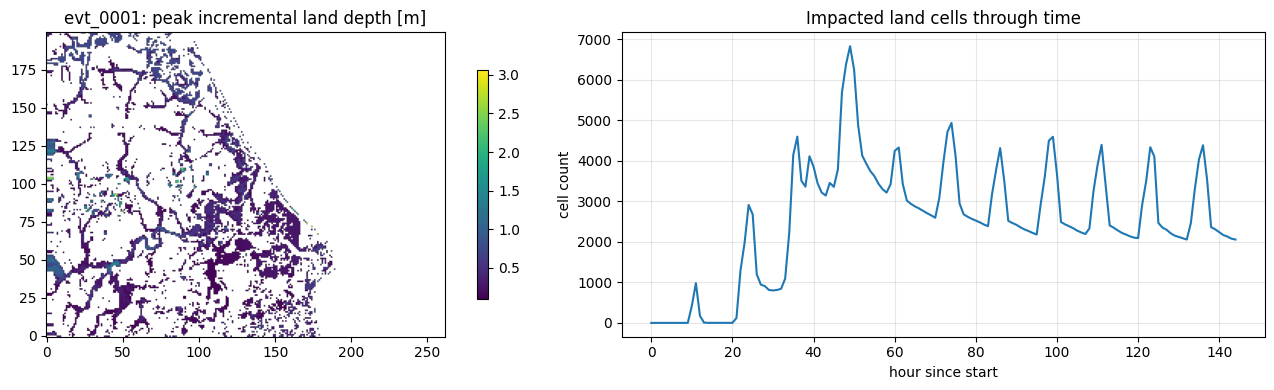

In [7]:
inp = stats.parse_sfincs_inp(event_dir / "sfincs.inp")
with xr.open_dataset(row["map_path"], decode_times=False) as ds:
    zs = np.asarray(ds["zs"].values, np.float32)
    zb = np.asarray(ds["zb"].values, np.float32)
    active = np.asarray(ds["msk"].values, float) > 0
    hours, dt = stats.parse_time(ds, inp)

depth = np.where(active[None, :, :], zs - zb[None, :, :], np.nan)
land = active & np.isfinite(zb) & (zb > settings["land_threshold_m"])
baseline = np.where(land, np.maximum(depth[0], 0.0), np.nan)
incremental = np.where(land[None, :, :], np.maximum(depth - np.nan_to_num(baseline, nan=0.0)[None, :, :], 0.0), np.nan)
impact = np.isfinite(incremental) & (incremental > settings["impact_threshold_m"])

peak_map = np.full(land.shape, np.nan, float)
impacted_cells = np.any(impact, axis=0)
if np.any(impacted_cells):
    peak_map[impacted_cells] = np.nanmax(np.where(impact, incremental, np.nan)[:, impacted_cells], axis=0)
impact_counts = impact.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(peak_map, origin="lower", cmap="viridis")
axes[0].set_title(f"{event_dir.name}: peak incremental land depth [m]")
fig.colorbar(im, ax=axes[0], shrink=0.75)

axes[1].plot(hours, impact_counts, lw=1.5)
axes[1].set_title("Impacted land cells through time")
axes[1].set_xlabel("hour since start")
axes[1].set_ylabel("cell count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5: Build the Stats Table

In [8]:
rows = []
for d in selected_events:
    rows.append(
        stats.event_stats(
            d,
            paths["storage_root"],
            settings["land_threshold_m"],
            settings["huthresh_m"],
            settings["impact_threshold_m"],
            scenario_summary,
            scenario_rows,
            design_rows,
            design_attrs,
        )
    )

df = pd.DataFrame(rows).sort_values("event_id").reset_index(drop=True)
display(df[[
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years",
    "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h",
]].head())

df.describe(include="all").T.head(20)

,event_id,design_scenario,design_slr_offset_m,sample_rp_years,expected_bzs_peak_max_m,bzs_peak_max_m,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2,longest_incremental_flood_duration_h
0,evt_0001,base,0.0,0.147906,1.749489,1.749,3.058504,None,133.0
1,evt_0002,base,0.0,0.044461,2.168041,2.168,3.419613,None,138.0
2,evt_0003,base,0.0,7.776219,2.642051,2.642,2.954899,None,134.0
3,evt_0004,base,0.0,0.274365,1.931400,1.931,3.065431,None,136.0
4,evt_0005,base,0.0,0.138144,1.692793,1.693,2.861057,None,136.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,12,12,evt_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scenario_dir,12,12,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_path,12,12,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
log_path,12,12,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_outputs_root,12,1,/home/grahamhults/projects/Flood-RM/locations/...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_scenario,12,1,base,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_slr_offset_m,12.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
source_event_index,12.0,NaN,NaN,NaN,6.5,3.605551,1.0,3.75,6.5,9.25,12.0
sample_rp_years,12.0,NaN,NaN,NaN,7.475504,23.160145,0.044461,0.056339,0.116553,0.284907,80.685832
probability_weight,12.0,NaN,NaN,NaN,0.000406,0.000162,0.000011,0.000475,0.000475,0.000475,0.000475


## Step 6: Check Alignment Between Inputs and Flood Outputs

- boundary peak from `sfincs.bzs` should track the design-event expected boundary peak.
- return period and SLR scenario should be available beside flood metrics.
- flood extent/depth rankings should point back to event IDs for map inspection.

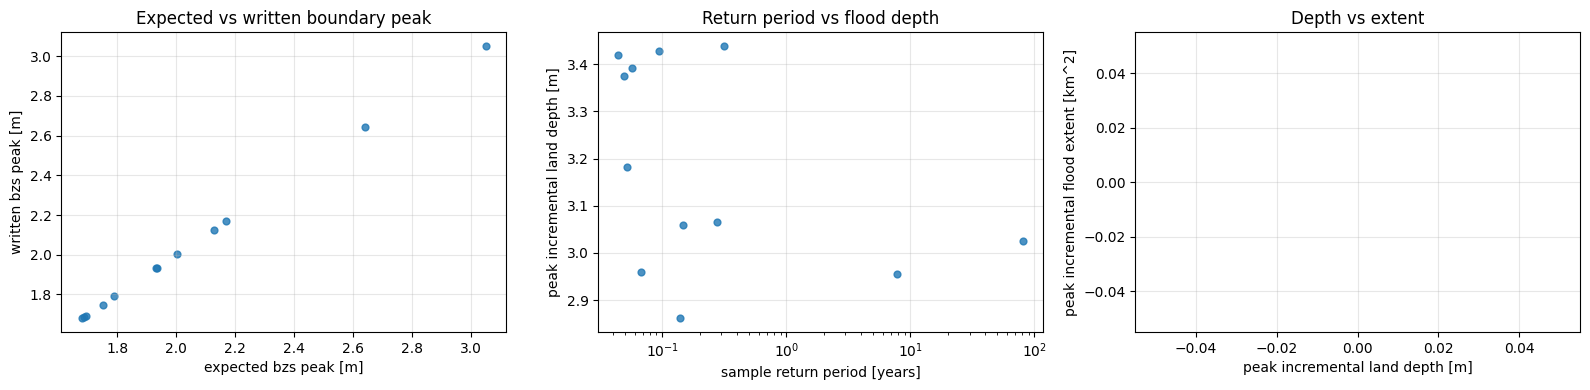

,event_id,design_scenario,sample_rp_years,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2
8,evt_0009,base,0.316533,3.438494,None
9,evt_0010,base,0.094962,3.427034,None
1,evt_0002,base,0.044461,3.419613,None
7,evt_0008,base,0.057627,3.392327,None
5,evt_0006,base,0.049603,3.373888,None
11,evt_0012,base,0.052476,3.181433,None
3,evt_0004,base,0.274365,3.065431,None
0,evt_0001,base,0.147906,3.058504,None
6,evt_0007,base,80.685832,3.025436,None
10,evt_0011,base,0.067922,2.959100,None


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df["expected_bzs_peak_max_m"], df["bzs_peak_max_m"], s=24, alpha=0.8)
axes[0].set_title("Expected vs written boundary peak")
axes[0].set_xlabel("expected bzs peak [m]")
axes[0].set_ylabel("written bzs peak [m]")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["sample_rp_years"], df["peak_incremental_land_depth_m"], s=24, alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_title("Return period vs flood depth")
axes[1].set_xlabel("sample return period [years]")
axes[1].set_ylabel("peak incremental land depth [m]")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df["peak_incremental_land_depth_m"], df["peak_incremental_flooded_area_km2"], s=24, alpha=0.8)
axes[2].set_title("Depth vs extent")
axes[2].set_xlabel("peak incremental land depth [m]")
axes[2].set_ylabel("peak incremental flood extent [km^2]")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df.sort_values("peak_incremental_land_depth_m", ascending=False)[["event_id", "design_scenario", "sample_rp_years", "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2"]].head(10)

## Step 7: Write Notebook Outputs

In [10]:
outdir = paths["stats_root"] / "notebook"
outdir.mkdir(parents=True, exist_ok=True)

csv_path = outdir / "scenario_stats_notebook.csv"
df.to_csv(csv_path, index=False)

metric_cols = [
    "zsini_m", "baseline_t0_flooded_area_km2", "peak_incremental_land_depth_m",
    "peak_incremental_flooded_area_km2", "anytime_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "mean_incremental_flood_duration_h",
    "area_incremental_flooded_ge_24h_km2",
]
summary = {
    "event_count": int(len(df)),
    "design_outputs_root": scenario_summary.get("design_outputs_root"),
    "design_scenarios": sorted(str(x) for x in df["design_scenario"].dropna().unique()),
    "design_slr_offsets_m": sorted(float(x) for x in pd.to_numeric(df["design_slr_offset_m"], errors="coerce").dropna().unique()),
    "metric_summaries": {c: stats.series_summary(df, c) for c in metric_cols},
}

(outdir / "summary_notebook.json").write_text(__import__("json").dumps(summary, indent=2), encoding="utf-8")
pd.Series({"csv": str(csv_path), "summary": str(outdir / "summary_notebook.json")})

csv        /home/grahamhults/projects/Flood-RM/locations/...
summary    /home/grahamhults/projects/Flood-RM/locations/...
dtype: str